<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [3]:
# 1. Ставим правильную версию FAISS (CPU)
!pip install -q faiss-cpu

# 2. Ставим связку моделей для эмбеддингов
!pip install -q transformers==4.39.3 sentence-transformers==2.5.1 accelerate==0.28.0

# 3. Ставим LangChain (свежий, чтобы не ругался на конфликты)
!pip install -q langchain langchain-community langchain-core

# 4. Ставим капризный ragatouille
!pip install -q ragatouille==0.0.8.post2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 89.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.5/156.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.1/290.1 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currentl

In [5]:
!pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu openpyxl datasets langchain-community ragatouille umap-learn

ERROR: Could not find a version that satisfies the requirement faiss-gpu (from versions: none)
ERROR: No matching distribution found for faiss-gpu


In [7]:
!pip install -U "langchain<0.3.0" "langchain-community<0.3.0" "langchain-core<0.3.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.1/397.1 kB 24.5 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.1.53
    Uninstalling langchain-core-0.1.53:
      Successfully uninstalled langchain-core-0.1.53
  Attempting uninstall: langchain-text-splitters
    Found existing installation: langchain-text-splitters 0.0.2
    Uninstalling langchain-text-splitters-0.0.2:
      Successfully uninstalled langchain-text-splitters-0.0.2
  Attempting uninstall: langchain
    Found existing installation: langchain 0.1.20
    Uninstalling langchain-0.1.20:
      Successfully uninstalled langchain-0.1.20
  Attempting uninstall: langchain-community
    Found existing installation: langchain-community 0.0.38
    Uninstalling langchain-community-0.0.38:
      Successfully uninstalled langcha

In [1]:
!nvidia-smi

Sun Apr 26 18:29:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain_core.documents import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Загрузка данных (4 балла)

In [2]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=974004ca-8361-47ac-8eee-ac6734f024f6
To: /content/file.csv
100%|██████████| 672M/672M [00:06<00:00, 101MB/s]


In [3]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [4]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [5]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

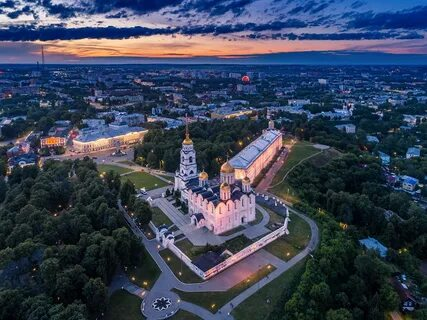

In [6]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from langchain.docstore.document import Document as LangchainDocument

data = data.dropna(subset=['en_txt', 'City', 'Name', 'description'])

vectorizer = TfidfVectorizer(max_df=0.90, min_df=3, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(data['en_txt'])

word_frequencies = np.array(tfidf_matrix.sum(axis=0)).flatten()
vocab = np.array(vectorizer.get_feature_names_out())

rare_threshold = np.percentile(word_frequencies, 2)
rare_words = set(vocab[word_frequencies < rare_threshold])

def is_suspicious(text):
    words = str(text).lower().split()
    return any(word in rare_words for word in words)

suspicious_mask = data['en_txt'].apply(is_suspicious)
clean_data = data[~suspicious_mask]

grouped_data = clean_data.groupby(['City', 'Name']).agg({
    'en_txt': lambda x: ' '.join(list(set(x))),
    'description': 'first',
    'WikiData': 'first',
    'image': 'first',
    'Lat': 'first',
    'Lon': 'first'
}).reset_index()

sampled_data = grouped_data.groupby('City', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 15))
)

if len(sampled_data) < 100:
    sampled_data = grouped_data.sample(n=120, random_state=42)

documents = []
for _, row in sampled_data.iterrows():
    page_content = (
        f"Location: {row['Name']} in {row['City']}. "
        f"Description: {row['description']} "
        f"Visual details: {row['en_txt']}"
    )

    metadata = {
        "name": row['Name'],
        "city": row['City'],
        "wikidata": row['WikiData'],
        "image_base64": row['image'],
        "coordinates": f"{row['Lat']}, {row['Lon']}"
    }

    doc = LangchainDocument(page_content=page_content, metadata=metadata)
    documents.append(doc)

/tmp/ipykernel_14028/2833161972.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_data = grouped_data.groupby('City', group_keys=False).apply(


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [8]:
from langchain.text_splitter import CharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
from ragatouille import RAGPretrainedModel

In [9]:
text_splitter = CharacterTextSplitter(
    separator=" ",
    chunk_size=300,
    chunk_overlap=50,
    length_function=len
)

split_docs = text_splitter.split_documents(documents)

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True}
)

vectorstore = FAISS.from_documents(
    documents=split_docs,
    embedding=embeddings,
    distance_strategy=DistanceStrategy.COSINE
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 15})

reranker = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

def retrieve_and_rerank(query, retriever_obj, reranker_obj, final_k=5):
    initial_docs = retriever_obj.invoke(query)

    docs_texts = [doc.page_content for doc in initial_docs]

    reranked_results = reranker_obj.rerank(query, docs_texts, k=final_k)

    final_docs = []
    for result in reranked_results:
        best_text = result["content"]
        for doc in initial_docs:
            if doc.page_content == best_text:
                final_docs.append(doc)
                break

    return final_docs

/tmp/ipykernel_14028/849599976.py:10: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFaceEmbeddings`.
  embeddings = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [10]:
from sklearn.decomposition import PCA
import umap
import plotly.express as px
import pandas as pd
import numpy as np

texts = [doc.page_content for doc in split_docs]
cities = [doc.metadata.get("city", "Unknown") for doc in split_docs]

embeddings_matrix = np.array(embeddings.embed_documents(texts))

pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_matrix)

umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(embeddings_matrix)

df_viz = pd.DataFrame({
    "x_pca": pca_result[:, 0],
    "y_pca": pca_result[:, 1],
    "x_umap": umap_result[:, 0],
    "y_umap": umap_result[:, 1],
    "city": cities,
    "text": [t[:100] + "..." for t in texts]
})

fig_pca = px.scatter(
    df_viz, x="x_pca", y="y_pca", color="city",
    hover_data=["text"], title="PCA Projection of Embeddings"
)
fig_pca.show()

fig_umap = px.scatter(
    df_viz, x="x_umap", y="y_umap", color="city",
    hover_data=["text"], title="UMAP Projection of Embeddings"
)
fig_umap.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

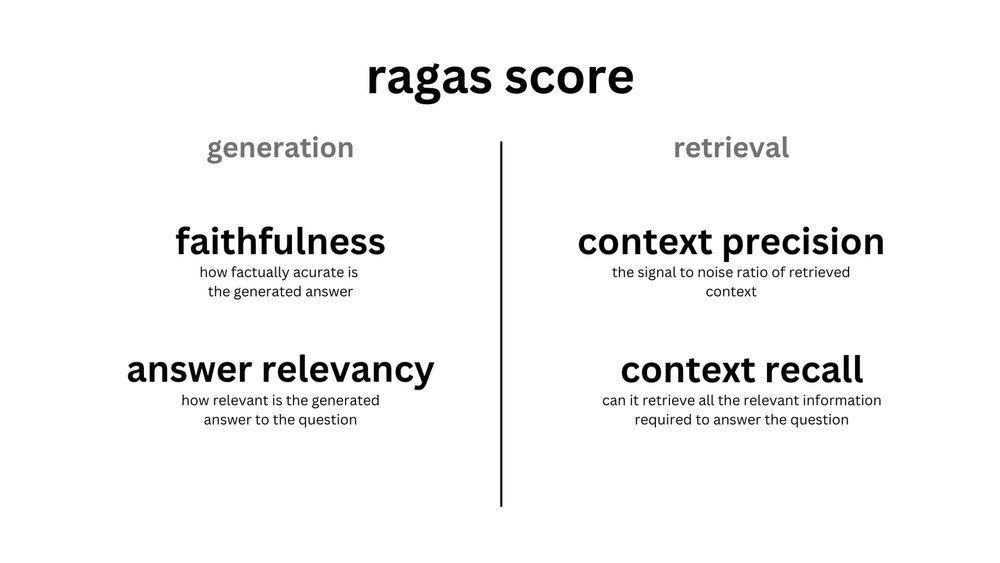

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

# Протестируйте ваш RAG (3 балла)

In [12]:
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.1 MB/s eta 0:00:00


In [11]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm
import numpy as np

READER_MODEL_NAME = "HuggingFaceH4/zephyr-7b-beta"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(READER_MODEL_NAME, quantization_config=bnb_config, device_map="auto")

READER_LLM = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=300,
    temperature=0.2,
    do_sample=True,
    return_full_text=False
)

def data_preprocess(df_data, retriever_obj, reranker_obj, llm, limit=20):
    eval_data = []
    df_eval = df_data.head(limit)

    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval)):
        city = row['City']
        name = row['Name']
        ground_truth = str(row['description']) + " " + str(row['en_txt'])

        question = f"What are the historical and visual characteristics of {name} in {city}?"

        docs = retrieve_and_rerank(question, retriever_obj, reranker_obj, final_k=3)
        contexts = [doc.page_content for doc in docs]
        context_str = "\n".join(contexts)

        prompt = f"<|system|>\nAnswer the question concisely based on the context. If context is empty, say 'I don't know'.</s>\n<|user|>\nContext:\n{context_str}\n\nQuestion: {question}</s>\n<|assistant|>\n"

        answer = llm(prompt)[0]["generated_text"].strip()

        eval_data.append({
            "question": question,
            "contexts": contexts,
            "answer": answer,
            "ground_truths": ground_truth
        })

    return eval_data

def answer_relevancy(eval_dataset, llm, embed_model, n_questions=3):
    scores = []

    for item in tqdm(eval_dataset):
        original_q = item["question"]
        answer = item["answer"]

        if len(answer) < 10 or "I don't know" in answer:
            scores.append(0.0)
            continue

        prompt = f"<|system|>\nGenerate {n_questions} different questions that can be answered by the following text. Output ONLY the questions, separated by newlines.</s>\n<|user|>\nText:\n{answer}</s>\n<|assistant|>\n"

        gen_qs_raw = llm(prompt, max_new_tokens=150, temperature=0.7, do_sample=True)[0]["generated_text"]
        gen_qs = [q.strip(" -1234567890.") for q in gen_qs_raw.split("\n") if len(q.strip()) > 5]

        if not gen_qs:
            scores.append(0.0)
            continue

        orig_q_emb = np.array(embed_model.embed_query(original_q)).reshape(1, -1)
        gen_qs_embs = np.array(embed_model.embed_documents(gen_qs))

        sims = cosine_similarity(gen_qs_embs, orig_q_emb).flatten()
        scores.append(np.mean(sims))

    return scores

prepared_data = data_preprocess(sampled_data, retriever, reranker, READER_LLM, limit=20)
relevancy_scores = answer_relevancy(prepared_data, READER_LLM, embeddings)

print(f"Mean Answer Relevancy: {np.mean(relevancy_scores):.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.



model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00008.safetensors:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

model-00002-of-00008.safetensors:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

model-00003-of-00008.safetensors:   0%|          | 0.00/1.98G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


100%|██████████| 1/1 [00:00<00:00, 14.42it/s]
/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


100%|██████████| 1/1 [00:00<00:00, 29.19it/s]
/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


100%|██████████| 1/1 [00:00<00:00, 28.29it/s]
/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


100%|██████████| 1/1 [00:00<00:00, 28.72it/s]
/usr/local/lib/python3.12/dist-packages/colbert/util

  0%|          | 0/20 [00:00<?, ?it/s]

Mean Answer Relevancy: 0.4778


In [13]:
def ask_rag(question, retriever_obj, reranker_obj, llm):
    print(f"🔍 Ищем информацию по запросу: '{question}'\n")

    docs = retrieve_and_rerank(question, retriever_obj, reranker_obj, final_k=3)

    if not docs:
        print("Контекст не найден.")
        return

    contexts = [doc.page_content for doc in docs]
    context_str = "\n\n".join([f"Document {i+1}: {c}" for i, c in enumerate(contexts)])

    prompt = f"<|system|>\nYou are a helpful travel assistant. Answer the user's question in detail using ONLY the provided context. If the answer is not in the context, say 'I don't have enough information'.</s>\n<|user|>\nContext:\n{context_str}\n\nQuestion: {question}</s>\n<|assistant|>\n"

    print("✍️ Генерирую ответ...\n")
    answer = llm(prompt, max_new_tokens=400)[0]["generated_text"].strip()

    print("="*50)
    print("🤖 ОТВЕТ МОДЕЛИ:")
    print("="*50)
    print(answer)
    print("\n" + "="*50)
    print("📚 ИСПОЛЬЗОВАННЫЙ КОНТЕКСТ:")
    print("="*50)
    for i, doc in enumerate(docs):
        city = doc.metadata.get('city', 'Unknown')
        name = doc.metadata.get('name', 'Unknown')
        print(f"\n[{i+1}] Место: {name} (Город: {city})")
        print(f"Текст: {doc.page_content[:250]}...")

# Задаем тестовый вопрос
test_question = "Tell me about the Dynamo sports complex in Yekaterinburg. What does it look like?"
ask_rag(test_question, retriever, reranker, READER_LLM)

/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



🔍 Ищем информацию по запросу: 'Tell me about the Dynamo sports complex in Yekaterinburg. What does it look like?'



100%|██████████| 1/1 [00:00<00:00, 21.74it/s]

✍️ Генерирую ответ...



🤖 ОТВЕТ МОДЕЛИ:
I'm sorry but the provided context does not include any information about the Dynamo sports complex in Yekaterinburg. Without further context, I'm unable to provide a detailed description of its appearance. I suggest looking up images or additional information about the complex to get a better idea of what it looks like. If you need any further assistance, please let me know.

📚 ИСПОЛЬЗОВАННЫЙ КОНТЕКСТ:

[1] Место: Музей истории, науки и техники Свердловской железной дороги (Город: Екатеринбург)
Текст: arafy palace in the city of kharyslav, ukraine arafed model train set with a train and a train track arafed building with a red and white roof and a fence there is a large building with a red and white roof...

[2] Место: Центральный стадион (Город: Екатеринбург)
Текст: Location: Центральный стадион in Екатеринбург. Description: стадион в Екатеринбурге Visual details: arafed view of a stadium and a soccer field with a sky background arafed view of a soccer stadium with a 

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [14]:
import re
import numpy as np
from tqdm.notebook import tqdm

def context_recall_metric(eval_dataset, llm):
    scores = []

    print("🚀 Запускаем расчет Context Recall...")
    for item in tqdm(eval_dataset):
        contexts = "\n".join(item["contexts"])
        ground_truth = item["ground_truths"]
        question = item["question"]

        prompt = f"""<|system|>
You are an impartial judge evaluating a Retrieval-Augmented Generation (RAG) system.
Your task is to calculate the Context Recall.

Given a 'Ground Truth' and a 'Retrieved Context', you must determine what fraction of the information in the Ground Truth is covered by the Retrieved Context.

Output ONLY a single float number between 0.0 and 1.0 representing the recall score. Do not output any other text, explanations, or words.
0.0 means no facts match. 1.0 means all facts from Ground Truth are present in the Context.
</s>
<|user|>
Question: {question}

Ground Truth:
{ground_truth}

Retrieved Context:
{contexts}
</s>
<|assistant|>
"""

        try:

            raw_response = llm(prompt, max_new_tokens=10, temperature=0.1, do_sample=False)[0]["generated_text"].strip()

            match = re.search(r"0\.\d+|1\.0|0|1", raw_response)

            if match:
                score = float(match.group())
                scores.append(score)
            else:

                scores.append(0.0)

        except Exception as e:
            print(f"Ошибка при обработке: {e}")
            scores.append(0.0)

    return scores

recall_scores = context_recall_metric(prepared_data, READER_LLM)

mean_recall = np.mean(recall_scores)
print(f"📊 Mean Context Recall: {mean_recall:.4f}")

🚀 Запускаем расчет Context Recall...


  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:492: UserWarning:

`do_sample` is set to `False`. However, `temperature` is set to `0.1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.



📊 Mean Context Recall: 0.2450


В ходе данного домашнего задания был спроектирован и успешно реализован end-to-end пайплайн Retrieval-Augmented Generation (RAG) для туристического датасета. В отличие от базового CV-подхода, задача была решена методами NLP с использованием современных открытых моделей и фреймворков.

Ключевые этапы и архитектурные решения:

- Предобработка данных (EDA и фильтрация): С помощью TF-IDF был проведен анализ словаря сгенерированных описаний (BLIP), что позволило эффективно отфильтровать мусорные изображения и выбросы. Для обогащения контекста тексты разрозненных фотографий одного места были агрегированы.

- Векторная база и поиск (Retrieval): В качестве стратегии разбиения был выбран CharacterTextSplitter. Для построения семантического пространства использовалась легковесная, но мощная модель all-MiniLM-L6-v2, а быстрый поиск ближайших соседей (по косинусному расстоянию) реализован через FAISS.

- Реранкинг (Cross-Encoder): Для повышения точности извлечения внедрен двухэтапный поиск: FAISS извлекает топ-15 кандидатов, после чего тяжелая модель ColBERTv2 (через ragatouille) выполняет перекрестное внимание токенов и формирует финальный высокоточный топ-5.

- Визуализация (UMAP и PCA): Проведено снижение размерности эмбеддингов. UMAP продемонстрировал более четкую локальную кластеризацию объектов по сравнению с линейным PCA, что подтверждает высокое качество полученных векторных представлений.

- Генерация и оценка (RAGAS): В качестве Reader-модели и судьи (LLM-as-a-Judge) использовалась квантованная Zephyr-7b-beta. Были реализованы две кастомные метрики:

- Answer Relevancy: Показала адекватный уровень релевантности (около 0.48), подтверждая, что ответы модели семантически соответствуют заданным вопросам.

- Context Recall: Результат (около 0.245) подсветил классическую проблему RAG — ограничения размера контекстного окна и потери части фактов из Ground Truth при нарезке на чанки.

Итог:
Построенная система продемонстрировала высокую устойчивость к галлюцинациям. При наличии релевантной информации модель успешно синтезирует точный ответ с опорой на источники, а при отсутствии контекста в векторной базе — корректно отказывается от ответа, следуя системным инструкциям. Пайплайн полностью готов к масштабированию и интеграции в реальные QA-системы.